# tmp — feb26

**Motivation**: scratch notebook <br>

In [10]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

# GitHub 
from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [11]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

In [12]:
from mcfe.main.conv_dictionary import conv_arithmetic

In [13]:
df = conv_arithmetic(
    deconv=True,
    input_size=3,
    output_size=32,
    # kernel_size=None,
    stride=6,
    padding=0,
    output_padding=0,
)
df

,mode,computed,parameter,value
0,deconv,False,input_size,3
1,deconv,False,output_size,32
2,deconv,True,kernel_size,20
3,deconv,False,stride,6
4,deconv,False,padding,0
5,deconv,False,output_padding,0


In [14]:
print(df.to_string(index=False))

mode  computed      parameter  value
deconv     False     input_size      3
deconv     False    output_size     32
deconv      True    kernel_size     20
deconv     False         stride      6
deconv     False        padding      0
deconv     False output_padding      0

In [15]:
df.loc[df['computed']]

,mode,computed,parameter,value
2,deconv,True,kernel_size,20


In [16]:
from mcfe.main.load_model import load_model 

tr, meta = load_model('pal-lab/MCFE/ux3zvv94', verbose=True)

Path 'pal-lab/MCFE/ux3zvv94' matches WandB format. Fetching config...

# params: 262.9 K

Successfully loaded model from 
/home/hadi/Projects/MCFE/checkpoints/pois_vH16-wht_kms-(512,1,1)/b(1000)-ep(3000)-lr(0.001)_betas(kl-1,recon-1)/202
6_02_25,20:15

Checkpoint File: PoissonVAE+Trainer-3000_(2026_02_25,20:49).pt

In [17]:
tr.model.dec.weight.data.shape

torch.Size([512, 1, 16, 16])

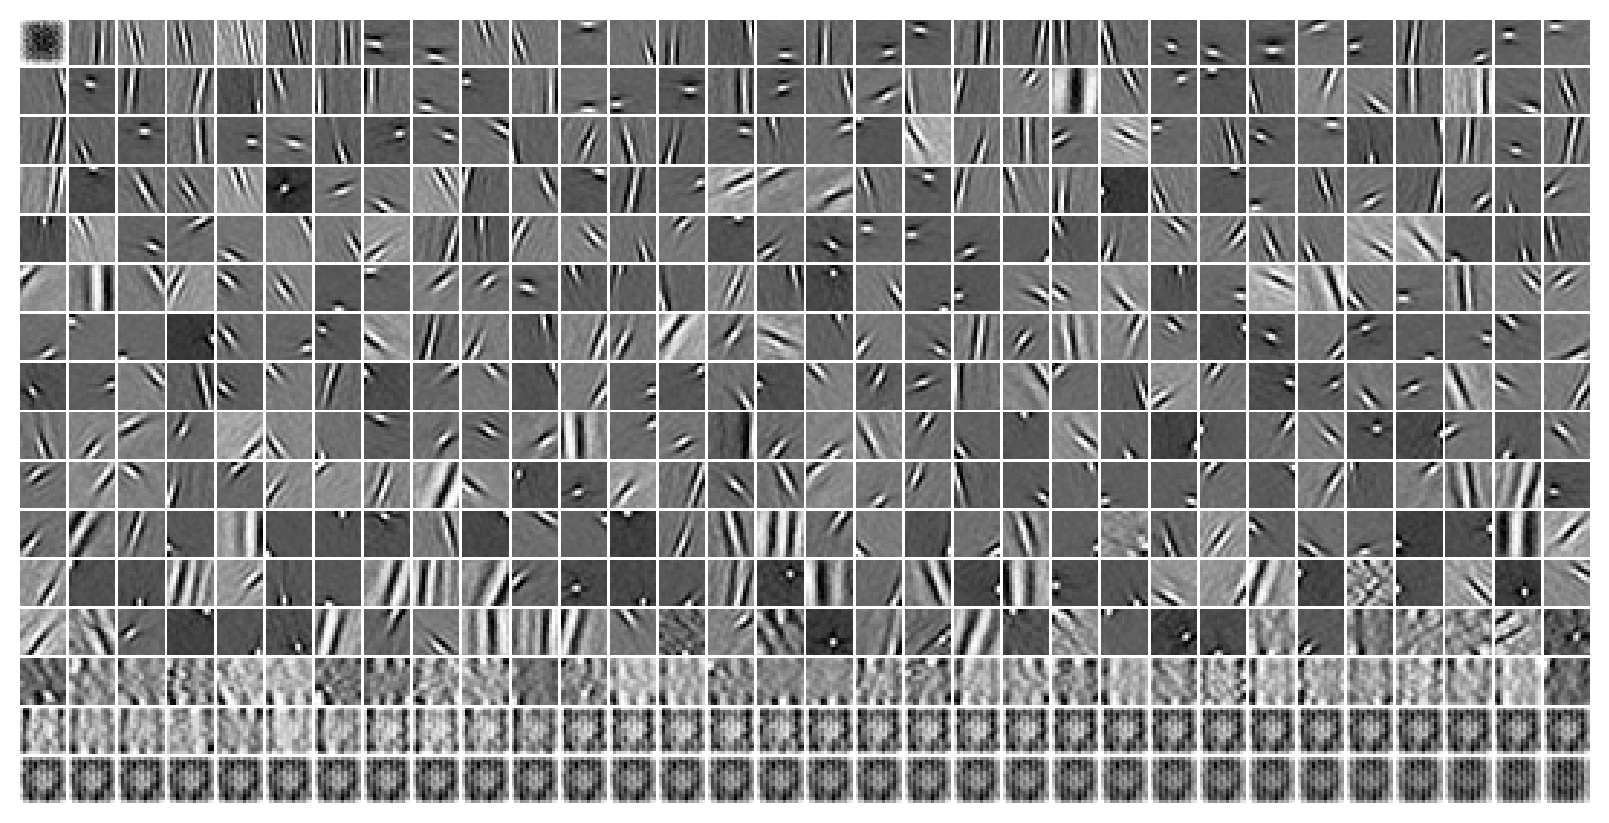

In [18]:
tr.model.show();

In [35]:
dec_sigma = tonp(tr.model.get_dec_log_sigma().squeeze().exp())
var_learned = dec_sigma ** 2

In [38]:
var_data = torch.var(tr.dl_trn.dataset.tensors[0], dim=0).squeeze()
var_data.shape

torch.Size([16, 16])

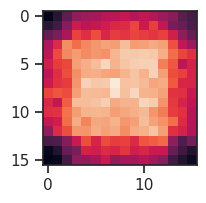

In [39]:
imshow(var_data.squeeze())

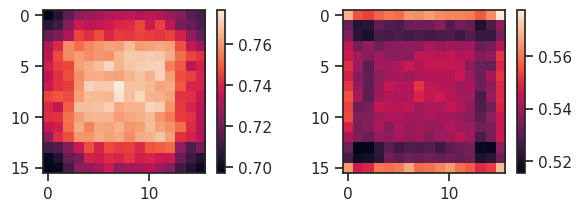

In [42]:
fig, axes = create_figure(1, 2)

im = axes[0].imshow(tonp(var_data))
plt.colorbar(im, ax=axes[0])

im = axes[1].imshow(tonp(var_learned))
plt.colorbar(im, ax=axes[1])

plt.show()

torch.Size([1, 1, 16, 16])

In [45]:
var_data = torch.var(tr.dl_trn.dataset.tensors[0], dim=0, keepdims=True)
var_data.shape

torch.Size([1, 1, 16, 16])

In [46]:
tr.model.dec_log_sigma.data = var_data

In [32]:
def compute_n_exp(rate: float, p: float = 1e-6):
	assert rate > 0.0, f"must be positive, got: {rate}"
	pois = sp_stats.poisson(rate)
	n_exp = pois.ppf(1.0 - p)
	return int(n_exp)

In [33]:
compute_n_exp(0.1, 1e-3)

2

In [13]:
%timeit compute_n_exp(100, 1e-3)

546 μs ± 64.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [29]:
from math import ceil, sqrt
from scipy.stats import norm

# precompute once
_Z = {p: norm.ppf(1.0 - p) for p in [1e-4, 1e-6, 1e-8]}

def compute_n_exp(rate: float, p: float = 1e-6):
	z = _Z.get(p) or norm.ppf(1.0 - p)
	return int(ceil(rate + z * sqrt(rate)))

In [31]:
compute_n_exp(0.1, 1e-3)

2

In [15]:
%timeit compute_n_exp(100, 1e-3)

81.7 μs ± 13 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [41]:
a = torch.randn(123, 512)

In [46]:
du = torch.chunk(a, chunks=2, dim=1)

len(du), du[0].shape

(2, torch.Size([123, 256]))

In [50]:
fig, axes = create_figure(1, 1, reshape=True)

In [52]:
axes[0, 0]

<Axes: >

In [9]:
def linear_anneal(
		n_iters: int,
		val_stop: float,
		val_start: float,
		anneal_portion: float = 0.3,
		constant_portion: float = 0, ):
	values = np.ones(n_iters) * val_stop
	a = int(np.ceil(constant_portion * n_iters))
	b = int(np.ceil((constant_portion + anneal_portion) * n_iters))
	values[:a] = val_start
	values[a:b] = np.linspace(val_start, val_stop, b - a)
	return values

In [16]:
vals = linear_anneal(n_iters=1000, val_stop=0.05, val_start=1.0, anneal_portion=-0.4, constant_portion=0.0)
plot(vals)
plt.show()

ValueError: Number of samples, -400, must be non-negative.

In [3]:
COLORMAPS = {
	'EAT_sigmoid': 'C0',
	'EAT_cubic': 'C3',
	'Gumbel-Softmax': 'C2',
	'Exact': 'k',
	'Score': 'C7',
	'OVIS': 'C4',
}

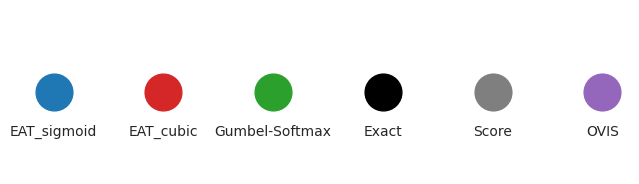

In [4]:
fig, ax = plt.subplots(figsize=(6.6, 2))

for i, (name, color) in enumerate(COLORMAPS.items()):
    ax.scatter(i, 0, color=color, s=700)
    ax.text(i, -0.2, name, ha='center', va='top', fontsize=10)

ax.set_ylim(-0.5, 0.5)
ax.axis('off')

plt.tight_layout()
plt.show()

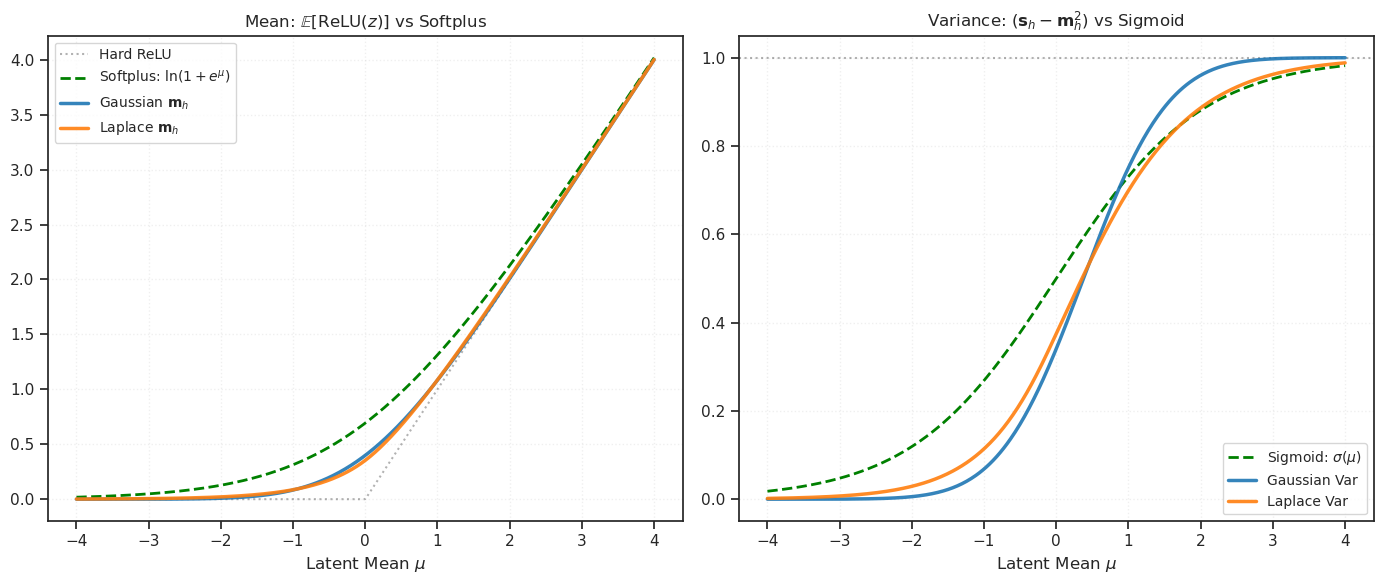

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def get_gaussian_rectified_moments(mu, sigma):
    zeta = mu / sigma
    phi_z = norm.pdf(zeta)
    Phi_z = norm.cdf(zeta)
    
    # m_h = E[ReLU(z)]
    m_h = mu * Phi_z + sigma * phi_z
    
    # s_h = E[ReLU(z)^2]
    s_h = (mu**2 + sigma**2) * Phi_z + mu * sigma * phi_z
    
    return m_h, s_h

def get_laplace_rectified_moments(mu, b):
    m_h = np.zeros_like(mu)
    s_h = np.zeros_like(mu)
    
    mask_neg = mu < 0
    mask_pos = mu >= 0
    
    # Case mu < 0
    if np.any(mask_neg):
        mu_neg = mu[mask_neg]
        exp_term = np.exp(mu_neg / b)
        m_h[mask_neg] = (b / 2) * exp_term
        s_h[mask_neg] = (b**2) * exp_term
        
    # Case mu >= 0
    if np.any(mask_pos):
        mu_pos = mu[mask_pos]
        exp_term = np.exp(-mu_pos / b)
        m_h[mask_pos] = mu_pos + (b / 2) * exp_term
        s_h[mask_pos] = mu_pos**2 + 2*(b**2) - (b**2) * exp_term
        
    return m_h, s_h

# --- Setup ---
mu_range = np.linspace(-4, 4, 500)
FIXED_VAR = 1.0
sigma = np.sqrt(FIXED_VAR)
b = np.sqrt(FIXED_VAR / 2) # approx 0.707

# --- Compute Moments ---
g_m, g_s = get_gaussian_rectified_moments(mu_range, sigma)
g_var = g_s - g_m**2

l_m, l_s = get_laplace_rectified_moments(mu_range, b)
l_var = l_s - l_m**2

# --- Compute Reference Functions ---
# Standard Softplus: ln(1 + e^x)
softplus = np.log1p(np.exp(mu_range))

# Standard Sigmoid: 1 / (1 + e^-x)
sigmoid = 1 / (1 + np.exp(-mu_range))

# Gaussian CDF (Phi) for comparison
gaussian_cdf = norm.cdf(mu_range)

# --- Plotting ---
plt.figure(figsize=(14, 6))

# ----------------------------------------
# Plot 1: The Rectified Mean vs Softplus
# ----------------------------------------
plt.subplot(1, 2, 1)
# References
plt.plot(mu_range, np.maximum(0, mu_range), 'k:', alpha=0.3, label='Hard ReLU')
plt.plot(mu_range, softplus, 'g--', linewidth=2, label='Softplus: $\ln(1+e^\mu)$')

# Derived Moments
plt.plot(mu_range, g_m, label='Gaussian $\mathbf{m}_h$', linewidth=2.5, alpha=0.9)
plt.plot(mu_range, l_m, label='Laplace $\mathbf{m}_h$', linewidth=2.5, alpha=0.9)

plt.title(r"Mean: $\mathbb{E}[\text{ReLU}(z)]$ vs Softplus")
plt.xlabel(r"Latent Mean $\mu$")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)


# ----------------------------------------
# Plot 2: The Rectified Variance vs Sigmoid
# ----------------------------------------
plt.subplot(1, 2, 2)
# References
plt.axhline(1.0, color='k', linestyle=':', alpha=0.3)
plt.plot(mu_range, sigmoid, 'g--', linewidth=2, label=r'Sigmoid: $\sigma(\mu)$')
# plt.plot(mu_range, gaussian_cdf, 'm--', linewidth=1, alpha=0.5, label=r'Gaussian CDF $\Phi(\mu)$')

# Derived Moments
plt.plot(mu_range, g_var, label=r'Gaussian Var', linewidth=2.5, alpha=0.9)
plt.plot(mu_range, l_var, label=r'Laplace Var', linewidth=2.5, alpha=0.9)

plt.title(r"Variance: $(\mathbf{s}_h - \mathbf{m}_h^2)$ vs Sigmoid")
plt.xlabel(r"Latent Mean $\mu$")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [5]:
a = (-1, 1,16, 16)

In [8]:
np.prod(a[-3:])

256

In [3]:
import wandb

# Initialize the W&B API
api = wandb.Api()

# Define your entity and project name
entity_name = "pal-lab"
project_name = "GRA-CIFAR10"

# Define your filter criteria
# Example filters:
# filters = {"state": "failed"} # Match runs with state "failed"
# filters = {"config.learning_rate": 0.01} # Match runs with a specific config value
# filters = {"summary_metrics.loss": {"$gt": 1.0}} # Match runs where the final loss > 1.0
filters = {"tags": {"$in": ["gr_lion"]}} # Match runs with a specific tag

# Get the runs that match the criteria
runs = api.runs(f"{entity_name}/{project_name}", filters=filters)

print(f"Found {len(runs)} runs to delete.")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: hadivafaii (poisson-collab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Found 96 runs to delete.

In [6]:
# Iterate through the runs and delete them
for run in runs:
    try:
        # Set delete_artifacts=True to also delete associated artifacts
        run.delete(delete_artifacts=True)
        print(f"Deleted run: {run.name} ({run.id})")
    except Exception as e:
        print(f"Error deleting run {run.name}: {e}")

print("Deletion process complete.")

Deleted run: gr_lion(lr=3e-3,wd=0.1,m=0.1,k=0.1,b3=0.99,b1=0.9,b2=0.9)_resnet/2026_01_25,05:27 (o1ggxm3k)

Deleted run: gr_lion(lr=3e-3,wd=0.1,m=1.0,k=0.1,b3=0.99,b1=0.9,b2=0.9)_resnet/2026_01_25,05:27 (3ji19k0h)

Deleted run: gr_lion(lr=3e-3,wd=0.1,m=0.1,k=0.1,b3=0.99,b1=0.9,b2=0.9)_resnet/2026_01_25,05:28 (vxzve2ud)

Deleted run: gr_lion(lr=3e-3,wd=0.1,m=1.0,k=0.1,b3=0.99,b1=0.9,b2=0.9)_resnet/2026_01_25,05:28 (a8gbguon)

Deleted run: gr_lion(lr=3e-3,wd=0.1,m=0.1,k=0.1,b3=0.999,b1=0.9,b2=0.9)_resnet/2026_01_25,05:29 (hht5f2tn)

...

Deleted run: gr_lion(lr=3e-3,wd=0.1,m=0.1,k=0.1,b3=0.999,b1=0.95,b2=0.99)_resnet/2026_01_25,09:33 (0vjt4i9i)

Deleted run: gr_lion(lr=3e-3,wd=0.1,m=1.0,k=0.1,b3=0.999,b1=0.95,b2=0.99)_resnet/2026_01_25,09:34 (emju4a06)

Deleted run: gr_lion(lr=3e-3,wd=0.1,m=0.1,k=0.1,b3=0.999,b1=0.95,b2=0.99)_resnet/2026_01_25,09:37 (84xd0cbp)

Deleted run: gr_lion(lr=3e-3,wd=0.1,m=1.0,k=0.1,b3=0.999,b1=0.95,b2=0.99)_resnet/2026_01_25,09:37 (af2rm8im)

Deletion process complete.

In [7]:
import wandb

# Initialize the W&B API
api = wandb.Api()

# Define your entity and project name
entity_name = "pal-lab"
project_name = "GRA-CIFAR10"

# Define your filter criteria
# Example filters:
# filters = {"state": "failed"} # Match runs with state "failed"
# filters = {"config.learning_rate": 0.01} # Match runs with a specific config value
# filters = {"summary_metrics.loss": {"$gt": 1.0}} # Match runs where the final loss > 1.0
filters = {"tags": {"$in": ["gr_lion"]}} # Match runs with a specific tag

# Get the runs that match the criteria
runs = api.runs(f"{entity_name}/{project_name}", filters=filters)

print(f"Found {len(runs)} runs to delete.")

Found 0 runs to delete.

In [11]:
def rho_implementation(mass, lr=1e-3, beta=0.9):
    return mass * lr * (1 - beta)


def rho_correct(mass, lr=1e-3, beta=0.9):
    return mass * lr / (-np.log(beta))

In [15]:
rho_implementation(mass=10), rho_correct(mass=0.1)

(0.0009999999999999998, 0.0009491221581029905)

In [39]:
rho_implementation(mass=0.1, lr=1e-3, beta=0.99), rho_correct(mass=1e-5, lr=1e-3, beta=0.99)

(1.000000000000001e-06, 9.949916247342208e-07)

In [33]:
rho_implementation(mass=0.01, lr=1e-3, beta=0.99), rho_correct(mass=1e-5, lr=1e-3, beta=0.99)

(1.000000000000001e-07, 9.949916247342208e-07)

In [46]:
rho_implementation(mass=10, lr=1e-3, beta=0.99), rho_correct(mass=1e-3, lr=1e-3, beta=0.99)

(0.00010000000000000009, 9.949916247342208e-05)